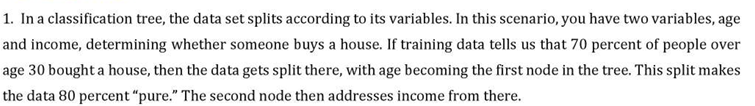

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn import tree

In [2]:
import pandas as pd
import numpy as np

np.random.seed(5)

# Generate 100 records
age = np.random.randint(21, 61, 100)
income = np.random.randint(25000, 120001, 100)

# House purchase rule
# Higher age and higher income increase the possibility of buying a house
buys_house = np.where(
    ((age >= 35) & (income >= 50000)) |
    ((age >= 45) & (income >= 40000)),
    1,
    0
)

# Create dataframe
df = pd.DataFrame({
    'Age': age,
    'Income': income,
    'Buys_House': buys_house
})

print(df)

    Age  Income  Buys_House
0    56   47804           1
1    35   80880           1
2    59   83578           1
3    37  112053           1
4    30   54423           0
..  ...     ...         ...
95   54   42521           1
96   49  104040           1
97   36   26928           0
98   27  106789           0
99   56   55862           1

[100 rows x 3 columns]


In [3]:
print("Dataset Shape:", df.shape)

print("\nFirst 10 records:")
print(df.head(10))

print("\nLast 10 records:")
print(df.tail(10))

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (100, 3)

First 10 records:
   Age  Income  Buys_House
0   56   47804           1
1   35   80880           1
2   59   83578           1
3   37  112053           1
4   30   54423           0
5   29   40668           0
6   57   34553           0
7   60   59618           1
8   48  119580           1
9   51   83204           1

Last 10 records:
    Age  Income  Buys_House
90   26   57922           0
91   39   59009           1
92   48   31902           0
93   50   49805           1
94   45   82182           1
95   54   42521           1
96   49  104040           1
97   36   26928           0
98   27  106789           0
99   56   55862           1

Missing Values:
Age           0
Income        0
Buys_House    0
dtype: int64


In [4]:
print("House Purchase Distribution:")
print(df['Buys_House'].value_counts())

print("\n0 = Does Not Buy House")
print("1 = Buys House")

House Purchase Distribution:
Buys_House
1    55
0    45
Name: count, dtype: int64

0 = Does Not Buy House
1 = Buys House


In [5]:
X = df[['Age', 'Income']]
y = df['Buys_House']

print("Independent Variables:")
print(X.head())

print("\nDependent Variable:")
print(y.head())

Independent Variables:
   Age  Income
0   56   47804
1   35   80880
2   59   83578
3   37  112053
4   30   54423

Dependent Variable:
0    1
1    1
2    1
3    1
4    0
Name: Buys_House, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80, 2)
Testing data: (20, 2)


In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=5
)

model.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [8]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[0 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 0 0]

Predicted Values:
[0 0 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 0 0]


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy in Percentage:", accuracy * 100, "%")

Accuracy Score: 1.0
Accuracy in Percentage: 100.0 %


In [10]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[ 9  0]
 [ 0 11]]


In [11]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



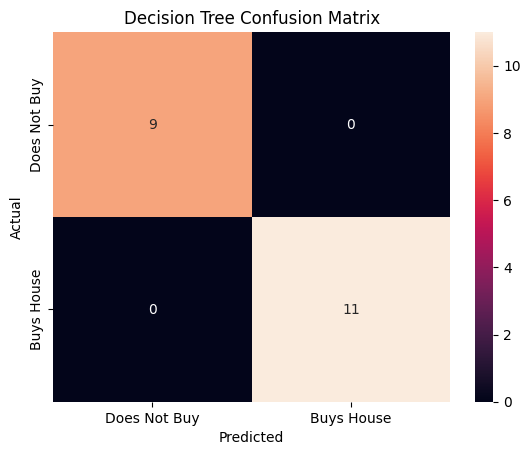

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    xticklabels=['Does Not Buy', 'Buys House'],
    yticklabels=['Does Not Buy', 'Buys House']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

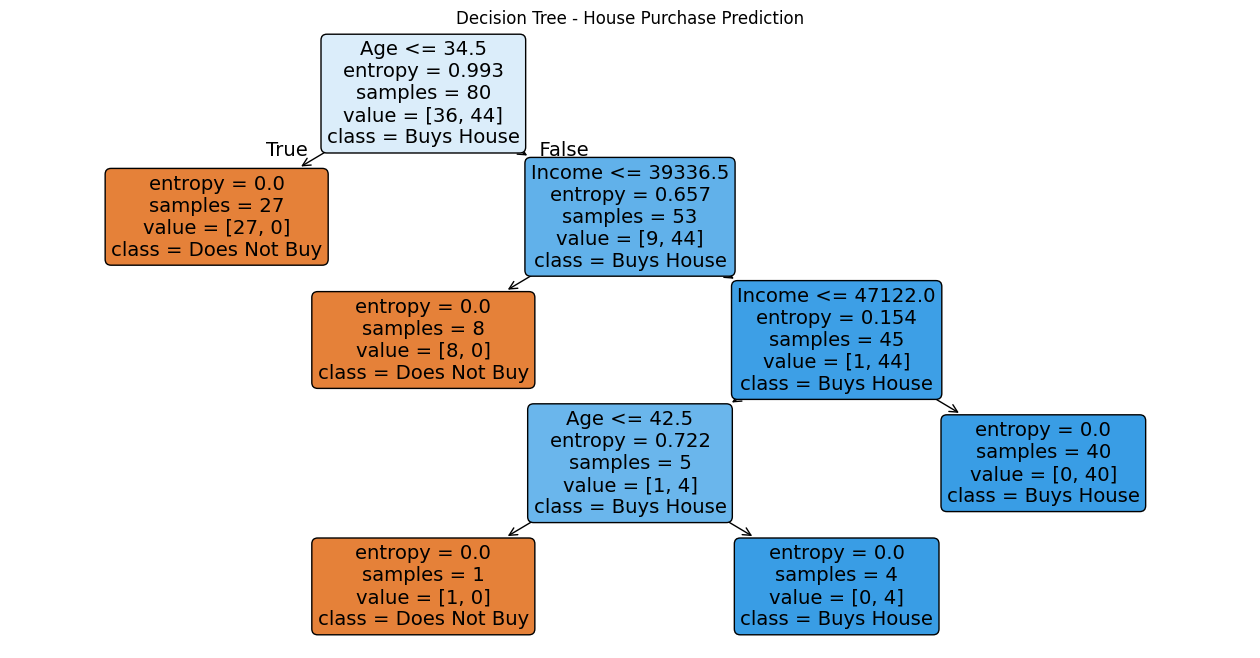

In [13]:
from sklearn import tree

plt.figure(figsize=(16, 8))

tree.plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['Does Not Buy', 'Buys House'],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - House Purchase Prediction")
plt.show()

In [14]:
importance = pd.DataFrame({
    'Feature': ['Age', 'Income'],
    'Importance': model.feature_importances_
})

print(importance)

  Feature  Importance
0     Age    0.606836
1  Income    0.393164


In [15]:
new_person = pd.DataFrame({
    'Age': [40],
    'Income': [65000]
})

prediction = model.predict(new_person)

if prediction[0] == 1:
    print("Prediction: Buys House")
else:
    print("Prediction: Does Not Buy House")

Prediction: Buys House
